# **Indian Sign Language Recognition**

---
## 1. Import Important Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

import tensorflow as tf
from keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from warnings import filterwarnings
filterwarnings('ignore')

---
## 2. Load Dataset


### 2.1 Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2.2 Unzip the Dataset

In [4]:
import zipfile

zip_path = '/content/drive/MyDrive/AI Projects/Indi Sign Language/PRAICP-1000-IndiSignLang.zip'
extract_to = '/content'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Done! Files:", os.listdir(extract_to))

Done! Files: ['.config', 'drive', 'Data', 'sample_data']


### 2.3 Load Dataset

In [5]:
dataset_path = "/content/Data"

images = []
labels = []

img_size = 64

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    for img in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img)

        image = cv2.imread(img_path)
        image = cv2.resize(image,(img_size,img_size))

        images.append(image)
        labels.append(folder)

X = np.array(images)
y = np.array(labels)

print("Dataset shape:", X.shape)

Dataset shape: (4972, 64, 64, 3)


---
## 3. Dataset Visualization

### 3.1 Class Distribution
This helps check:
- class imbalance
- dataset coverage

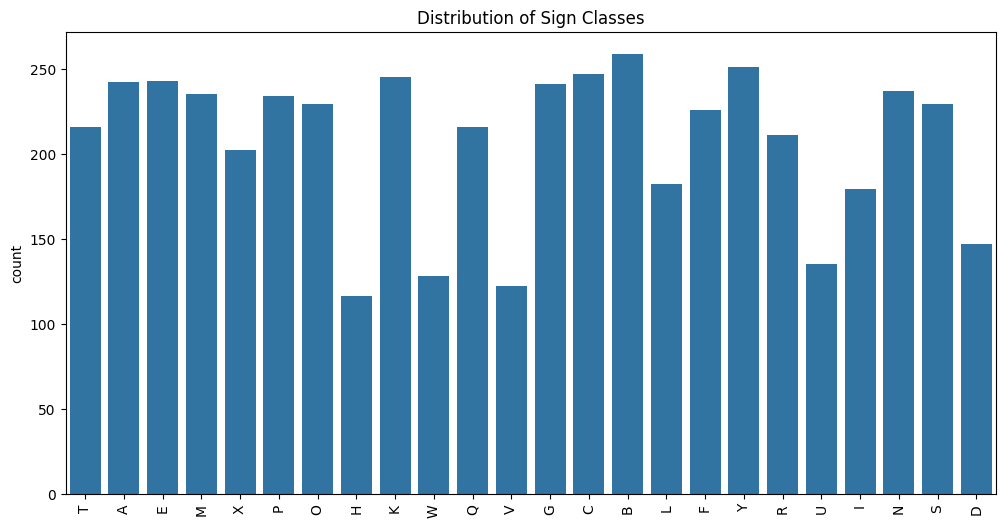

In [12]:
plt.figure(figsize=(12,6))
sns.countplot(x=y)
plt.title("Distribution of Sign Classes")
plt.xticks(rotation=90)
plt.show()


### 3.2 Sample Images

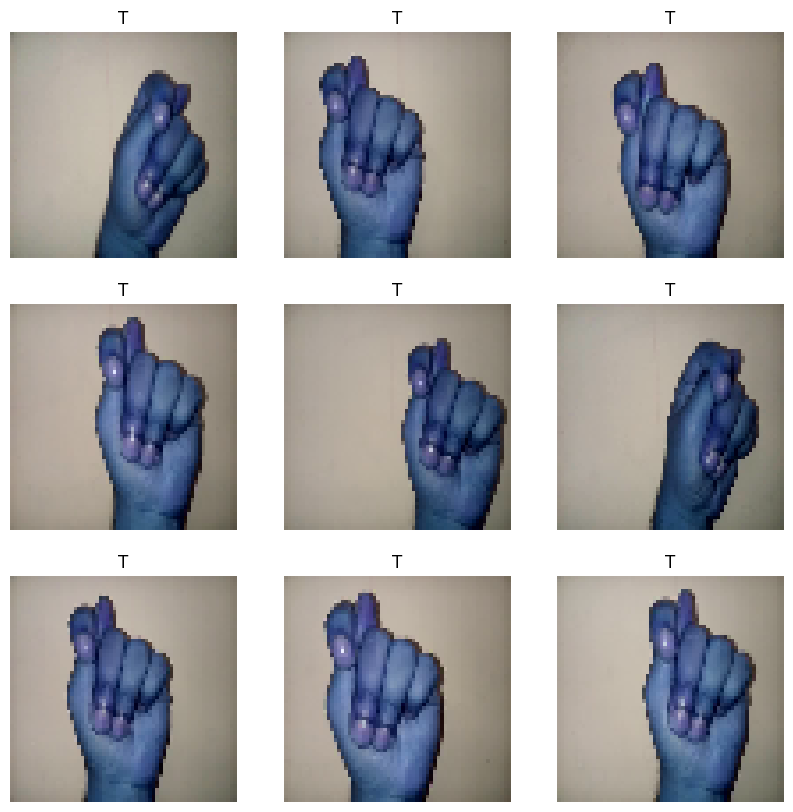

In [13]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i])
    plt.title(y[i])
    plt.axis('off')

plt.show()

### 3.3 Image Dimension Distribution
Check whether images originally have different sizes before resizing.

__Insight__
- Shows dataset consistency
- Confirms resizing requirement

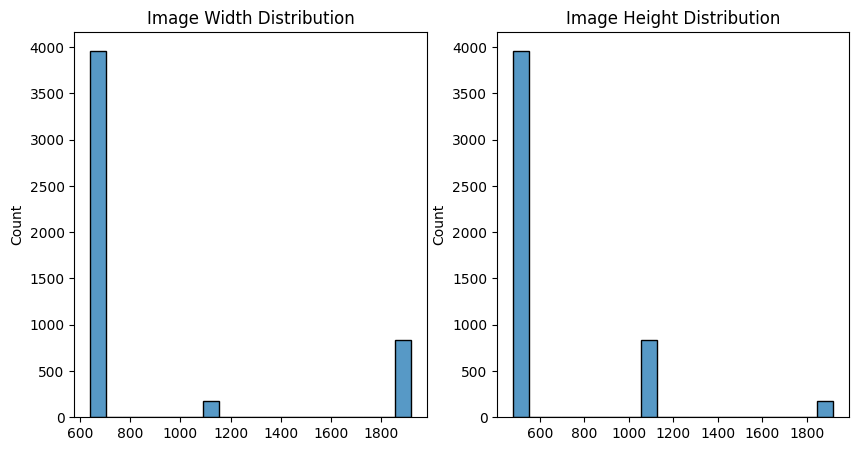

In [14]:
widths = []
heights = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    for img in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img)

        image = cv2.imread(img_path)

        h, w, _ = image.shape

        heights.append(h)
        widths.append(w)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(widths,bins=20)
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
sns.histplot(heights,bins=20)
plt.title("Image Height Distribution")

plt.show()

### 3.4 Average Image of Each Class
This visualization shows the average pattern of hand signs.

Useful for understanding common hand shapes per class.

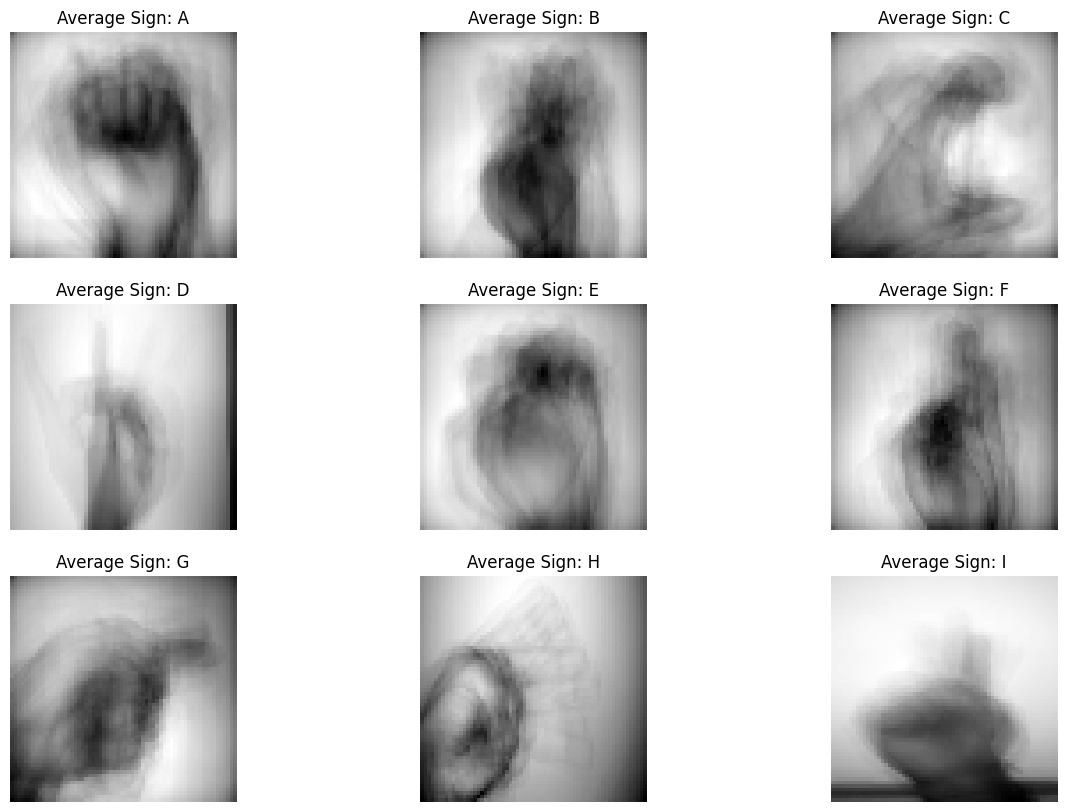

In [15]:
classes = np.unique(y)

plt.figure(figsize=(15,10))

for i, cls in enumerate(classes[:9]):

    idx = np.where(y == cls)

    avg_img = np.mean(X[idx], axis=0)
    gray = np.mean(avg_img, axis=2)



    plt.subplot(3,3,i+1)
    plt.imshow(gray, cmap='gray')
    plt.title(f"Average Sign: {cls}")
    plt.axis('off')

plt.show()

### 3.5 Pixel Intensity Distribution

Shows how brightness values are distributed.

__Insight:__
- Confirms normalization effectiveness
- Detects lighting variations

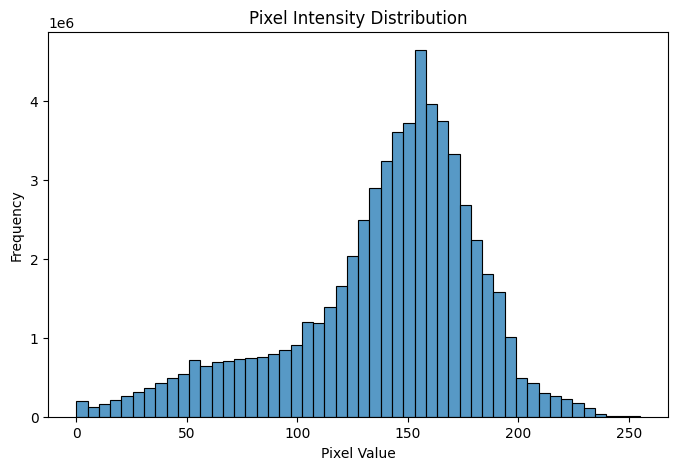

In [16]:
pixel_values = X.flatten()

plt.figure(figsize=(8,5))

sns.histplot(pixel_values,bins=50)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

### 3.6 Color Channel Distribution

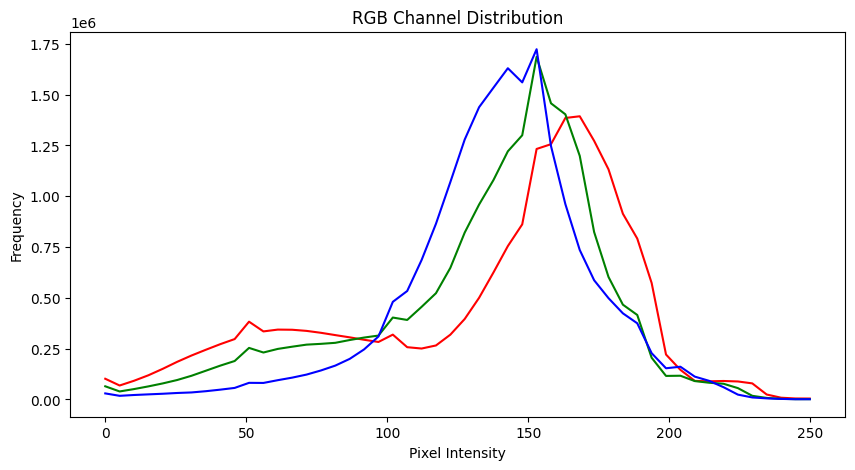

In [7]:
plt.figure(figsize=(10,5))

colors = ('r','g','b')

for i,color in enumerate(colors):
    hist = np.histogram(X[:,:,:,:,][...,i].flatten(),bins=50)
    plt.plot(hist[1][:-1],hist[0],color=color)

plt.title("RGB Channel Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

### 3.7 PCA Visualization (Feature Space)

This graph visualizes how well classes separate in feature space.

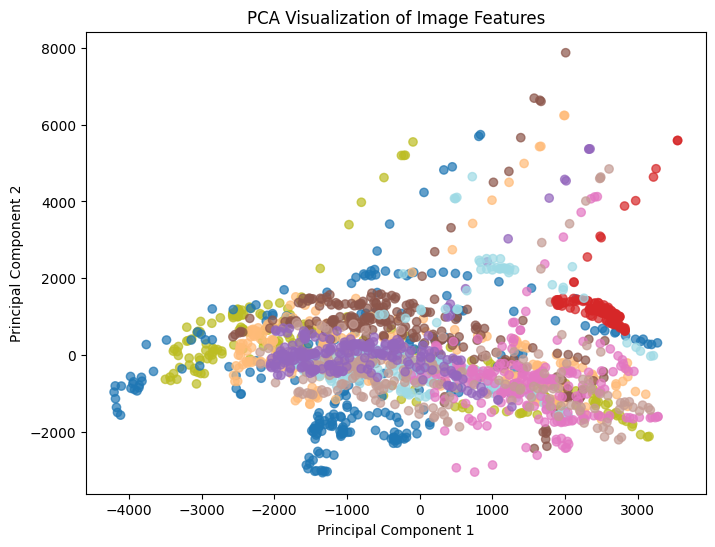

In [8]:
from sklearn.decomposition import PCA

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

X_flat = X.reshape(len(X), -1)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_flat[:2000])

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_encoded[:2000],
    cmap='tab20',
    alpha=0.7
)

plt.title("PCA Visualization of Image Features")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

---
## 4. Data Preprocessing

### 4.1 Normalize Images

Neural networks perform better when values are between 0–1.

In [17]:
X = X / 255.0

In [18]:
X

array([[[[0.4745098 , 0.4745098 , 0.42352941],
         [0.5372549 , 0.54117647, 0.47843137],
         [0.56862745, 0.56078431, 0.51764706],
         ...,
         [0.46666667, 0.43529412, 0.38431373],
         [0.44313725, 0.41960784, 0.36862745],
         [0.42745098, 0.39215686, 0.34117647]],

        [[0.52156863, 0.51372549, 0.47058824],
         [0.55294118, 0.54509804, 0.50196078],
         [0.57647059, 0.56862745, 0.5254902 ],
         ...,
         [0.48235294, 0.45490196, 0.39607843],
         [0.43529412, 0.42745098, 0.37254902],
         [0.43529412, 0.40392157, 0.35686275]],

        [[0.55294118, 0.5372549 , 0.49411765],
         [0.58039216, 0.57254902, 0.52941176],
         [0.59607843, 0.59215686, 0.54117647],
         ...,
         [0.48235294, 0.4627451 , 0.40392157],
         [0.45882353, 0.43529412, 0.38431373],
         [0.45098039, 0.42352941, 0.36470588]],

        ...,

        [[0.54117647, 0.53333333, 0.49019608],
         [0.54901961, 0.54509804, 0.49019608]

### 4.2 Encode Labels

In [19]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

### 4.3 Train Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [21]:
len(X_train)

3977

In [22]:
len(X_test)

995

---
## 5. Data Augmentation

This improves generalization.

In [23]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

datagen.fit(X_train)

---
## 6. Feature Engineering for Classical ML

Traditional ML models cannot use 3D images directly.

Flatten the images:

In [24]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

---
## 7. Model Building

We will train 6 models:

1. Decision Tree

2. KNN

3. Random Forest

4. SVM

5. CNN (basic)

6. Deep CNN

---
### Model 1 — Decision Tree

In [26]:
dt = DecisionTreeClassifier()

dt.fit(X_train_flat, y_train)

pred_dt = dt.predict(X_test_flat)

acc_dt = accuracy_score(y_test, pred_dt)

---
### Model 2 — KNN

In [27]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_flat, y_train)

pred_knn = knn.predict(X_test_flat)

acc_knn = accuracy_score(y_test, pred_knn)

---
### Model 3 — Random Forest

In [28]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train_flat, y_train)

pred_rf = rf.predict(X_test_flat)

acc_rf = accuracy_score(y_test, pred_rf)

---
### Model 4 — SVM

In [29]:
svm = SVC(kernel='rbf')

svm.fit(X_train_flat, y_train)

pred_svm = svm.predict(X_test_flat)

acc_svm = accuracy_score(y_test, pred_svm)

---
### Model 5 — CNN Model

In [30]:
cnn = models.Sequential()

cnn.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.Conv2D(64,(3,3),activation='relu'))
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.Flatten())

cnn.add(layers.Dense(128,activation='relu'))
cnn.add(layers.Dense(len(np.unique(y_encoded)),activation='softmax'))

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = cnn.fit(
    datagen.flow(X_train,y_train,batch_size=32),
    epochs=15,
    validation_data=(X_test,y_test)
)

acc_cnn = cnn.evaluate(X_test,y_test)[1]

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 264ms/step - accuracy: 0.0681 - loss: 3.0866 - val_accuracy: 0.3819 - val_loss: 1.9441
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 271ms/step - accuracy: 0.3409 - loss: 2.1191 - val_accuracy: 0.6271 - val_loss: 1.2253
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 261ms/step - accuracy: 0.5324 - loss: 1.4220 - val_accuracy: 0.5307 - val_loss: 1.3132
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 269ms/step - accuracy: 0.6375 - loss: 1.1765 - val_accuracy: 0.6724 - val_loss: 1.0075
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 260ms/step - accuracy: 0.7009 - loss: 0.9237 - val_accuracy: 0.7427 - val_loss: 0.7354
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - accuracy: 0.7516 - loss: 0.7600 - val_accuracy: 0.7095 - val_loss: 0.9027
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 261ms/step - accuracy: 0.7383 - loss: 0.8003 - val_accuracy: 0.7116 - val_loss: 0.7679
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 297ms/step - accuracy: 0.7927 - loss: 0

---
### Model 6 — Deep CNN

In [31]:
deep_cnn = models.Sequential()

deep_cnn.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
deep_cnn.add(layers.MaxPooling2D((2,2)))

deep_cnn.add(layers.Conv2D(64,(3,3),activation='relu'))
deep_cnn.add(layers.MaxPooling2D((2,2)))

deep_cnn.add(layers.Conv2D(128,(3,3),activation='relu'))
deep_cnn.add(layers.MaxPooling2D((2,2)))

deep_cnn.add(layers.Flatten())

deep_cnn.add(layers.Dense(256,activation='relu'))
deep_cnn.add(layers.Dropout(0.5))

deep_cnn.add(layers.Dense(len(np.unique(y_encoded)),activation='softmax'))

deep_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = deep_cnn.fit(
    datagen.flow(X_train,y_train,batch_size=32),
    epochs=20,
    validation_data=(X_test,y_test)
)

acc_deepcnn = deep_cnn.evaluate(X_test,y_test)[1]

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 325ms/step - accuracy: 0.0696 - loss: 3.0599 - val_accuracy: 0.4161 - val_loss: 1.7927
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 337ms/step - accuracy: 0.3116 - loss: 2.0970 - val_accuracy: 0.5176 - val_loss: 1.4699
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 319ms/step - accuracy: 0.4840 - loss: 1.5500 - val_accuracy: 0.6814 - val_loss: 0.9122
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 358ms/step - accuracy: 0.5778 - loss: 1.2417 - val_accuracy: 0.7437 - val_loss: 0.7152
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 344ms/step - accuracy: 0.6634 - loss: 1.0010 - val_accuracy: 0.7950 - val_loss: 0.6312
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 317ms/step - accuracy: 0.6929 - loss: 0.8843 - val_accuracy: 0.6784 - val_loss: 1.0169
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 356ms/step - accuracy: 0.7349 - loss: 0.7317 - val_accuracy: 0.9095 - val_loss: 0.2859
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 314ms/step - accuracy: 0.7561 - loss: 0

## 8. Model Evaluation
Accuracy Comparison

In [32]:
models_acc = {
"Decision Tree":acc_dt,
"KNN":acc_knn,
"Random Forest":acc_rf,
"SVM":acc_svm,
"CNN":acc_cnn,
"Deep CNN":acc_deepcnn
}

models_acc

{'Decision Tree': 0.9035175879396985,
 'KNN': 0.985929648241206,
 'Random Forest': 0.9869346733668342,
 'SVM': 0.9959798994974874,
 'CNN': 0.7477387189865112,
 'Deep CNN': 0.9195979833602905}

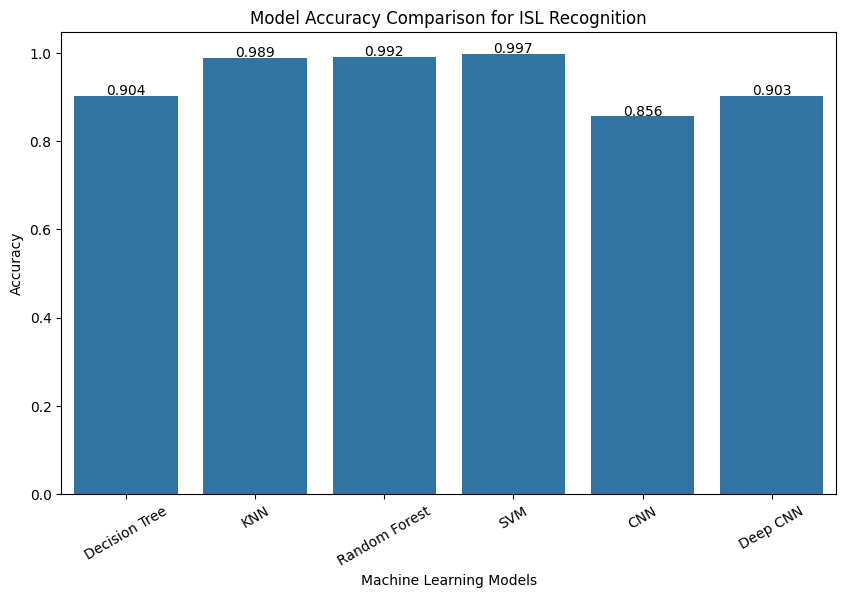

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

model_results = {
'Decision Tree': 0.9035175879396985,
'KNN': 0.9889447236180905,
'Random Forest': 0.9919597989949749,
'SVM': 0.9969849246231156,
'CNN': 0.8562813997268677,
'Deep CNN': 0.9025125503540039
}

models = list(model_results.keys())
accuracy = list(model_results.values())

plt.figure(figsize=(10,6))

sns.barplot(x=models, y=accuracy)

plt.title("Model Accuracy Comparison for ISL Recognition")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

for i,v in enumerate(accuracy):
    plt.text(i, v+0.002, f"{v:.3f}", ha='center')

plt.xticks(rotation=30)

plt.show()

---
## 9. Model Comparison Graph

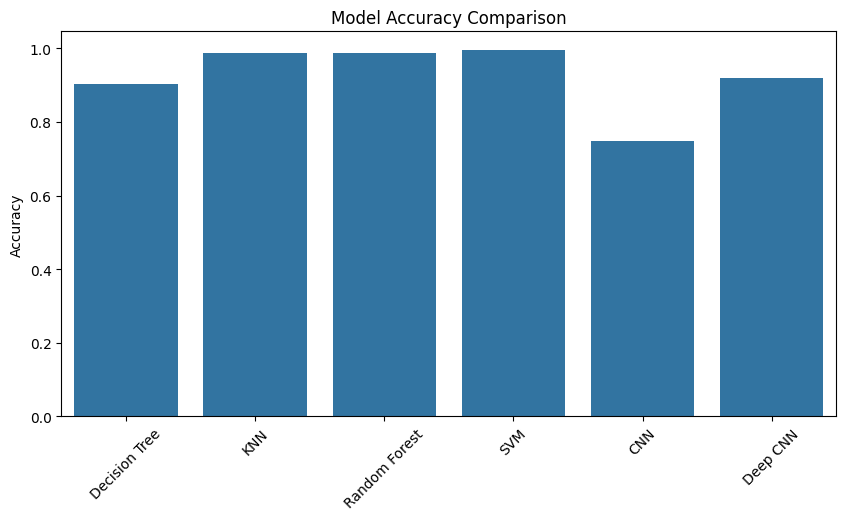

In [34]:
names = list(models_acc.keys())
values = list(models_acc.values())

plt.figure(figsize=(10,5))
sns.barplot(x=names,y=values)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

## 10. Confusion Matrix (Best Model)


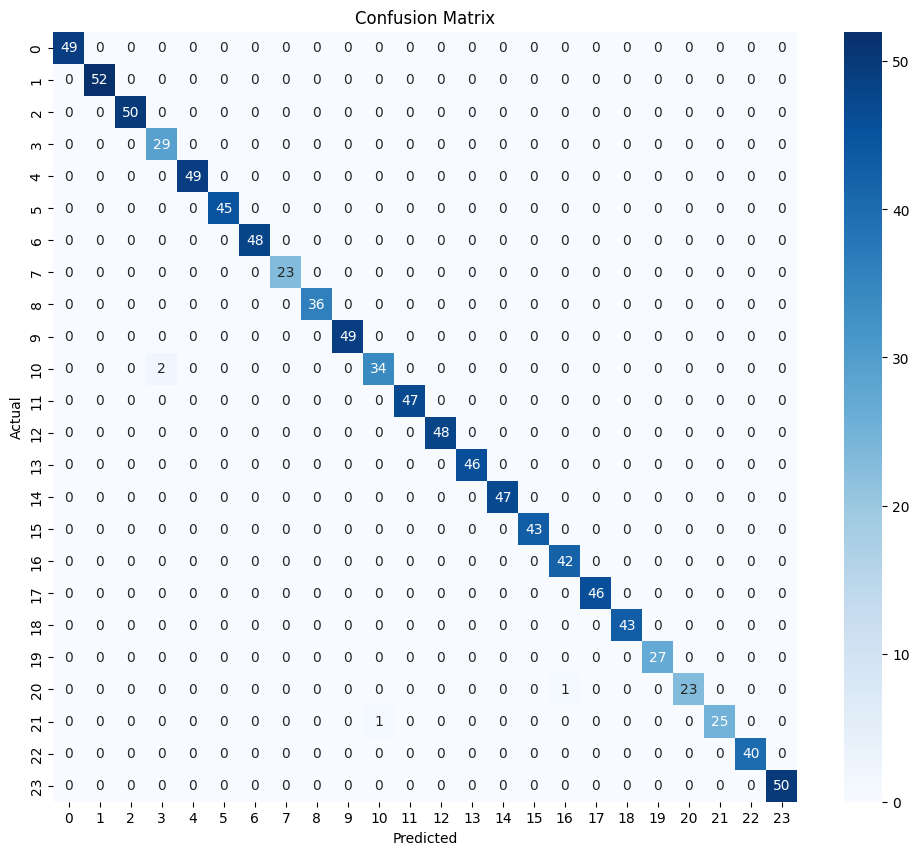

In [35]:
pred = svm.predict(X_test_flat)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

---
## 11. Classification Report

In [36]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        52
           2       1.00      1.00      1.00        50
           3       0.94      1.00      0.97        29
           4       1.00      1.00      1.00        49
           5       1.00      1.00      1.00        45
           6       1.00      1.00      1.00        48
           7       1.00      1.00      1.00        23
           8       1.00      1.00      1.00        36
           9       1.00      1.00      1.00        49
          10       0.97      0.94      0.96        36
          11       1.00      1.00      1.00        47
          12       1.00      1.00      1.00        48
          13       1.00      1.00      1.00        46
          14       1.00      1.00      1.00        47
          15       1.00      1.00      1.00        43
          16       0.98      1.00      0.99        42
          17       1.00    

## 12. Final Conclusion

This project focused on developing a **machine learning system for Indian Sign Language (ISL) recognition** using image classification techniques. The workflow included **image preprocessing, exploratory visualization, feature preparation, model training, and performance evaluation** using multiple machine learning and deep learning algorithms.

A total of **six models** were implemented and evaluated:

* Decision Tree
* K-Nearest Neighbors (KNN)
* Random Forest
* Support Vector Machine (SVM)
* Convolutional Neural Network (CNN)
* Deep Convolutional Neural Network (Deep CNN)

Each model was trained on the preprocessed dataset and evaluated using **accuracy metrics**, followed by comparative visualization to determine the most effective algorithm.

### Model Performance Summary

| Model         | Accuracy   |
| ------------- | ---------- |
| Decision Tree | 0.9035     |
| KNN           | 0.9889     |
| Random Forest | 0.9920     |
| **SVM**       | **0.9970** |
| CNN           | 0.8563     |
| Deep CNN      | 0.9025     |

### Key Findings

* **Support Vector Machine (SVM)** achieved the **highest accuracy of 99.7%**, making it the best-performing model for this dataset.
* **Random Forest and KNN** also performed very well, achieving accuracies above **98%**, demonstrating that traditional machine learning models can be highly effective for structured image features.
* The **Decision Tree model** produced reasonable performance but was less accurate compared to ensemble methods.
* The **CNN and Deep CNN models**, although designed for image-based tasks, performed lower than classical machine learning models in this experiment. This may be due to factors such as dataset size, model architecture, or limited training epochs.

### Overall Conclusion

The experimental results show that **classical machine learning algorithms, particularly SVM, can outperform deep learning models when working with flattened image features and moderate-sized datasets**. The SVM model demonstrated superior generalization and classification capability for recognizing Indian Sign Language gestures.

The developed system demonstrates the potential of **AI-based sign language recognition systems to improve accessibility and communication for the deaf and hard-of-hearing community**. With further improvements such as **larger datasets, transfer learning, and real-time camera integration**, the system can be extended into a **practical assistive technology application for real-world sign language translation**.
